In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os

load_dotenv('.env')
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite-preview",
    temperature=0.0,
    api_key=os.getenv('google_api_key')
)
llm

ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 3.1 Flash Lite Preview', 'release_date': '2026-03-03', 'last_updated': '2026-03-03', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-3.1-flash-lite-preview', temperature=0.0, client=<google.genai.client.Client object at 0x000002C9428DCAC0>, default_metadata=(), model_kwargs={})

In [2]:
# Agent to respond on emails
# (first agent Triage filter email then
# if its good email pass to ReAct Agent to use available tools and respond)
# if its spam email dont pass to ReAct Agent
# if its important email to notify so (notify: but will leave it empty in this code)

# First thing after Schema drawn is prompts:
## prompts
from pydantic import BaseModel, Field
from typing_extensions import TypedDict, Literal, Annotated

profile = {
    "name": "John",
    "full_name": "John Doe",
    "user_profile_background": "Senior software engineer leading a team of 5 developers",
}

prompt_instructions = {
    "triage_rules": {
        "ignore": "Marketing newsletters, spam emails, mass company announcements",
        "notify": "Team member out sick, build system notifications, project status updates",
        "respond": "Direct questions from team members, meeting requests, critical bug reports",
    },
    "agent_instructions": "Use these tools when appropriate to help manage User's tasks efficiently."
}

# Example incoming email
email = {
    "from": "Alice Smith <alice.smith@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "body": """
Hi John,

I was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?

Specifically, I'm looking at:
- /auth/refresh
- /auth/validate

Thanks!
Alice""",
}

# schema for Router Model (classify & resoning why this classification)
class Router(BaseModel):
    """Analyze the unread email and route it according to its content."""

    reasoning: str = Field(
        description="Step-by-step reasoning behind the classification."
    )
    classification: Literal["ignore", "respond", "notify"] = Field(
        description="The classification of an email: 'ignore' for irrelevant emails, "
        "'notify' for important information that doesn't need a response, "
        "'respond' for emails that need a reply",
    )

llm_router = llm.with_structured_output(Router) # Tagging
llm_router

RunnableBinding(bound=ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 3.1 Flash Lite Preview', 'release_date': '2026-03-03', 'last_updated': '2026-03-03', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-3.1-flash-lite-preview', temperature=0.0, client=<google.genai.client.Client object at 0x000002C9428DCAC0>, default_metadata=(), model_kwargs={}), kwargs={'response_mime_type': 'application/json', 'response_json_schema': {'description': 'Analyze the unread email and route it accord

In [3]:
# prepare prompts (could be from langsmith hub also)
import importlib
import email_task_templates

importlib.reload(email_task_templates) # to handle pycache the module
triage_system_prompt = email_task_templates.triage_system_prompt
triage_user_prompt = email_task_templates.triage_user_prompt
print(triage_system_prompt)


< Role >
You are {full_name}'s executive assistant. You are a top-notch executive assistant who cares about {name} performing as well as possible.
</ Role >

< Background >
{user_profile_background}. 
</ Background >

< Instructions >

{name} gets lots of emails. Your job is to categorize each email into one of three categories:

1. IGNORE - Emails that are not worth responding to or tracking
2. NOTIFY - Important information that {name} should know about but doesn't require a response
3. RESPOND - Emails that need a direct response from {name}

Classify the below email into one of these categories.

</ Instructions >

< Rules >
Emails that are not worth responding to:
{triage_no}

There are also other things that {name} should know about, but don't require an email response. For these, you should notify {name} (using the `notify` response). Examples of this include:
{triage_notify}

Emails that are worth responding to:
{triage_email}
</ Rules >

< Few shot examples >
{examples}

Here

In [4]:
# now modify this template to be prompt
system_prompt = triage_system_prompt.format(
    full_name=profile["full_name"],
    name=profile["name"],
    examples=None,
    user_profile_background=profile["user_profile_background"],
    triage_no=prompt_instructions["triage_rules"]["ignore"],
    triage_notify=prompt_instructions["triage_rules"]["notify"],
    triage_email=prompt_instructions["triage_rules"]["respond"],
)

user_prompt = triage_user_prompt.format(
    author=email["from"],
    to=email["to"],
    subject=email["subject"],
    email_thread=email["body"],
)

# try out the llm
result = llm_router.invoke(
    [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
)
result

Router(reasoning="Alice is a team member asking a direct question regarding project documentation that requires John's technical input to clarify the status of specific API endpoints.", classification='respond')

In [5]:
#### Define Main Agent now (ReAct) to solve the task using tools
# First tools & llm.bind_tools()
# Second AgentState across Graph
# Third build Graph (node for LLM and node for execute)

# First tools
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
from typing_extensions import TypedDict
from typing import Annotated
import operator

@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    # Placeholder response - in real app would send email
    return f"Email sent to {to} with subject '{subject}'"

@tool
def schedule_meeting(
    attendees: list[str], 
    subject: str, 
    duration_minutes: int, 
    preferred_day: str
) -> str:
    """Schedule a calendar meeting."""
    # Placeholder response - in real app would check calendar and schedule
    return f"Meeting '{subject}' scheduled for {preferred_day} with {len(attendees)} attendees"

@tool
def check_calendar_availability(day: str) -> str:
    """Check calendar availability for a given day."""
    # Placeholder response - in real app would check actual calendar
    return f"Available times on {day}: 9:00 AM, 2:00 PM, 4:00 PM"



#### 1) Episodic Memory:

* 1) Create Store with few_short examples

* 2) Update Router (or LLM you want to enhance in a task) prompt to accept examples [already done in templates.py]

* 3) Update Router_calling in LangGraph_Agent_Class to query most similar few_shots to his input

In [6]:
# Episodic Memory - 1) Create Store with few_short examples
from langchain_ollama import OllamaEmbeddings
from langgraph.store.sqlite import SqliteStore
import sqlite3

embedding_model = OllamaEmbeddings(model="nomic-embed-text")

conn_episodic = sqlite3.connect("email_respond_agent_episodic_memory.db", check_same_thread=False,
                            isolation_level=None # ← fixes the transaction error
)
episodic_memory = SqliteStore(
    conn_episodic,
    index={"embed": embedding_model, "dims": 768}
)

episodic_memory

In [7]:
# few-shot examples

example_1 = {
    "author": "Alice Smith <alice.smith@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "email_thread": """Hi John,

I was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?

Specifically, I'm looking at:
- /auth/refresh
- /auth/validate

Thanks!
Alice""",
}
label_1 = 'respond'

example_2 = {
    "author": "Tom Jones <tome.jones@bar.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "email_thread": """Hi John - want to buy documentation?""",
}
label_2 = 'ignore'

data_list = [{"email": example_1, 'label': label_1}, {'email': example_2, 'label': label_2}]

In [8]:
# insert batches in database
from langgraph.store.base import PutOp # for batching
import uuid

def chunked_bulk_put(store, namespace, items: list[dict], chunk_size: int = 256):
    """Push items to store in chunks to avoid memory/transaction overload."""
    
    total  = len(items)
    chunks = range(0, total, chunk_size)
    for i, start in enumerate(chunks):
        chunk = items[start : start + chunk_size]
        
        ops = [
            PutOp(
                namespace=namespace,
                key=str(uuid.uuid4()),
                value=item
            )
            for item in chunk
        ]
        
        store.batch(ops)
        print(f"✅ Chunk {i+1}/{len(chunks)} pushed ({len(chunk)} items)")
    print(f"🎉 Done — {total} items pushed total")


chunked_bulk_put(
    store=episodic_memory,
    namespace=("email_assistant", "lance", "examples"), # lance is username-space
    items=data_list,
    chunk_size=256 # chunk_size
)

✅ Chunk 1/1 pushed (2 items)
🎉 Done — 2 items pushed total


In [9]:
template = """Email Subject: {subject}
Email From: {from_email}
Email To: {to_email}
Email Content: 
```
{content}
```
> Triage Result: {result}"""

def format_few_shot_examples(examples):
    strs = ["Here are some previous examples:"]
    for eg in examples:
        strs.append(
            template.format(
                subject=eg.value["email"]["subject"],
                to_email=eg.value["email"]["to"],
                from_email=eg.value["email"]["author"],
                content=eg.value["email"]["email_thread"][:400],
                result=eg.value["label"],
            )
        )
    return "\n\n------------\n\n".join(strs)

#### Usage
email_data = {
        "author": "Sarah Chen <sarah.chen@company.com>",
        "to": "John Doe <john.doe@company.com>",
        "subject": "Update: Backend API Changes Deployed to Staging",
        "email_thread": """Hello John - want free documents their?""",
    }
results = episodic_memory.search(
    ("email_assistant", "lance", "examples"),
    query=str({"email": email_data}),
    limit=2)
print(format_few_shot_examples(results))

Here are some previous examples:

------------

Email Subject: Quick question about API documentation
Email From: Tom Jones <tome.jones@bar.com>
Email To: John Doe <john.doe@company.com>
Email Content: 
```
Hi John - want to buy documentation?
```
> Triage Result: ignore

------------

Email Subject: Quick question about API documentation
Email From: Alice Smith <alice.smith@company.com>
Email To: John Doe <john.doe@company.com>
Email Content: 
```
Hi John,

I was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?

Specifically, I'm looking at:
- /auth/refresh
- /auth/validate

Thanks!
Alice
```
> Triage Result: respond


#### 2) Semantic Memory:

* 1) configure memory tools (specfic namespace for each user)

* 2) define config

In [10]:
# * 1) configure memory tools (specfic namespace for each user)

# quick fix (langmem require python 3.11 but I have 3.10 so solve with sht solns)
import typing
import typing_extensions

if not hasattr(typing, "NotRequired"):
    typing.NotRequired = typing_extensions.NotRequired  # backport it

from langmem import create_manage_memory_tool, create_search_memory_tool
manage_memory_tool = create_manage_memory_tool(
    namespace=(
        "email_assistant", 
        "{langgraph_user_id}",
        "collection"
    )
)
search_memory_tool = create_search_memory_tool(
    namespace=(
        "email_assistant",
        "{langgraph_user_id}",
        "collection"
    )
)

print(f"manage_memory_tool.name: {manage_memory_tool.name}")
print(f"manage_memory_tool.args: {manage_memory_tool.args}")
print(f"manage_memory_tool.description: {manage_memory_tool.description}")
print("\n" + '*'*50 + '\n')
print(f"search_memory_tool.name: {search_memory_tool.name}")
print(f"search_memory_tool.args: {search_memory_tool.args}")
print(f"search_memory_tool.description: {search_memory_tool.description}")

tools = [write_email, schedule_meeting, check_calendar_availability, manage_memory_tool, search_memory_tool]

c:\Users\ahmed\anaconda3\envs\agentic_env\lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


manage_memory_tool.name: manage_memory
manage_memory_tool.args: {'content': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Content'}, 'action': {'default': 'create', 'enum': ['create', 'update', 'delete'], 'title': 'Action', 'type': 'string'}, 'id': {'anyOf': [{'format': 'uuid', 'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Id'}}
manage_memory_tool.description: Create, update, or delete a memory to persist across conversations.
Include the MEMORY ID when updating or deleting a MEMORY. Omit when creating a new MEMORY - it will be created for you.
Proactively call this tool when you:

1. Identify a new USER preference.
2. Receive an explicit USER request to remember something or otherwise alter your behavior.
3. Are working and want to record important context.
4. Identify that an existing MEMORY is incorrect or outdated.

**************************************************

search_memory_tool.name: search_memory
search_memory_tool.args: {'

In [11]:
# Second AgentState across whole Graph
class AgentState(TypedDict):
    messages : Annotated[list[BaseMessage], operator.add]
    email_input: dict

#### 3) Procedural Memory:

* 1) Put/Insert current system_prompt in procedural_memory_db

* 2) Optimize Prompts from outside using langmem for a specific use_case [kind = 'prompt_memory' there is other types in langmem documentation]

In [12]:
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from typing import Literal

# Third build Graph (node for LLM and node for execute)
class EmailRespondAgent:

    def __init__(self, llm, tools, memories, system_prompt=""):
        self.llm = llm
        self.initial_system_prompt = system_prompt
        self.tools_map = {tool.name: tool for tool in tools}
        self.llm_router = llm.with_structured_output(Router)
        self.llm_with_tools  = llm.bind_tools(tools)
        graph = StateGraph(AgentState)
        graph.add_node("triage_router",  self.llm_router_node)
        graph.add_node('response_agent', self.response_agent)
        graph.add_node('execute_tool', self.execute_tool)

        # Edges
        graph.add_edge(START, "triage_router")   # entry point
        graph.add_conditional_edges('response_agent', self.should_continue, {True:'execute_tool', False: END})
        graph.add_edge('execute_tool', 'response_agent')
        self.episodic_memory = memories['episodic_memory']
        self.procedural_memory = memories['procedural_memory']
        self.graph = graph.compile(checkpointer=memories['short_term_memory'], store=memories['long_term_memory'])

    def get_prompt(self, get_or_create_namespace: str, class_name: str, namespace: tuple[str]):
        store_result = self.procedural_memory.get(namespace, get_or_create_namespace)
        if store_result is None:
            self.procedural_memory.put(
                namespace, 
                get_or_create_namespace, 
                {"prompt": prompt_instructions["triage_rules"][class_name]}
            )
            prompt = prompt_instructions["triage_rules"][class_name]
        else:
            prompt = store_result.value['prompt']
        return prompt

    def create_system_prompt(self, config):
        langgraph_user_id = config['configurable']['langgraph_user_id']
        namespace = (langgraph_user_id, )
        store_result = self.procedural_memory.get(namespace, "agent_instructions")
        if store_result is None:
            self.procedural_memory.put(
                namespace, 
                "agent_instructions", 
                {"prompt": prompt_instructions["agent_instructions"]}
            )
            prompt = prompt_instructions["agent_instructions"]
        else:
            prompt = store_result.value['prompt']

        system_prompt = email_task_templates.react_agent_system_prompt.format(instructions=prompt, **profile)
        return system_prompt
 
    def llm_router_node(self, state: AgentState, config) -> Command[Literal['response_agent', '__end__']]:
        # Episodic Memory - 3) Update Router_calling in LangGraph_Agent_Class to query most similar few_shots to his input
        # Procedural Memory - 1) Put/Insert current system_prompt in procedural_memory_db 
        author = state['email_input']['author']
        to = state['email_input']['to']
        subject = state['email_input']['subject']
        email_thread = state['email_input']['email_thread']

        namespace = (
            "email_assistant",
            config['configurable']['langgraph_user_id'],
            "examples"
        )
        examples = self.episodic_memory.search(
            namespace, 
            query=str({"email": state['email_input']})
        ) 
        examples=format_few_shot_examples(examples)

        langgraph_user_id = config['configurable']['langgraph_user_id']
        namespace = (langgraph_user_id, )
        
        ignore_prompt = self.get_prompt(get_or_create_namespace='triage_ignore', class_name='ignore', namespace=namespace)
        notify_prompt = self.get_prompt(get_or_create_namespace='triage_notify', class_name='notify', namespace=namespace)
        respond_prompt = self.get_prompt(get_or_create_namespace='triage_respond', class_name='respond', namespace=namespace)
        
        system_prompt = triage_system_prompt.format(
            full_name=profile["full_name"],
            name=profile["name"],
            user_profile_background=profile["user_profile_background"],
            triage_no=ignore_prompt,
            triage_notify=notify_prompt,
            triage_email=respond_prompt,
            examples=examples
        )
        user_prompt = triage_user_prompt.format(
            author=author, 
            to=to, 
            subject=subject, 
            email_thread=email_thread
        )
        response = self.llm_router.invoke(
            [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ]
        )
        response_clf = response.classification
        if response_clf == 'respond':
            print("📧 Classification: RESPOND - This email requires a response")
            goto = 'response_agent'
            update = {
                "messages": [HumanMessage(content=f"Respond to the email {state['email_input']}")] # passing in messages a HumanMessage with email_input
            }

        elif response_clf == 'ignore':
            print("🚫 Classification: IGNORE - This email can be safely ignored")
            goto = END
            update = None # dont update

        elif response_clf == 'notify':
            # If real life, this would do something else
            print("🔔 Classification: NOTIFY - This email contains important information")
            goto = END
            update = None # dont update

        else:
            raise ValueError(f"Invalid classification: {result.classification}")

        return Command(goto=goto, update=update)

    def response_agent(self, state: AgentState, config):
        messages = state['messages']
        if not(self.initial_system_prompt): # if self.system_prompt doesn't exist put extracted one in it other use self.system_prompt
            self.system_prompt = self.create_system_prompt(config=config)
        else:
            self.system_prompt = self.initial_system_prompt

        messages = [SystemMessage(content=self.system_prompt)] + messages
        response = self.llm_with_tools.invoke(messages)
        return {'messages': [response]}
    
    def execute_tool(self, state: AgentState):
        last_message = state['messages'][-1]
        tool_results = []
        for tool_call in last_message.tool_calls:
            tool_fn = self.tools_map[tool_call["name"]]
            result  = tool_fn.invoke(tool_call["args"])
            tool_results.append(
                ToolMessage(
                    content=str(result),
                    tool_call_id=tool_call["id"],
                    name=tool_call["name"],
                )
            )
        return {"messages": tool_results}
    
    def should_continue(self, state: AgentState):
        last_message = state["messages"][-1]
        if last_message.tool_calls:
            return True
        return False

In [13]:
# * 2) define config
# define embedding for long_term_memory
from langgraph.checkpoint.sqlite import SqliteSaver

embedding_model = OllamaEmbeddings(model="nomic-embed-text")

conn = sqlite3.connect("email_respond_agent_short_term_memory.db", check_same_thread=False)
short_term_memory = SqliteSaver(conn)

# Long-term
conn_long = sqlite3.connect("email_respond_agent_long_term_memory.db", check_same_thread=False,
                            isolation_level=None # ← fixes the transaction error
)
long_term_memory = SqliteStore(
    conn_long,
    index={"embed": embedding_model, "dims": 768}
)

# Procedural memory
conn_procedural = sqlite3.connect("email_respond_agent_procedural_memory.db", check_same_thread=False,
                            isolation_level=None # ← fixes the transaction error
)
procedural_memory = SqliteStore(
    conn_procedural,
    index={"embed": embedding_model, "dims": 768}
)

memories = {'long_term_memory': long_term_memory, 'short_term_memory': short_term_memory, 'episodic_memory':episodic_memory, 'procedural_memory':procedural_memory}
email_respond_multiagent = EmailRespondAgent(llm=llm, tools=tools, memories=memories)
email_respond_multiagent

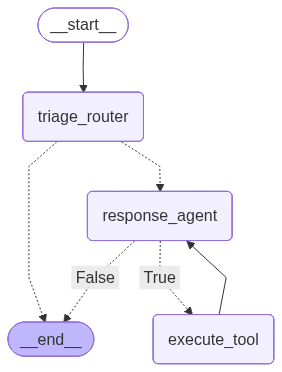

In [14]:
email_respond_multiagent.graph

In [15]:
# example_1
email_input = {
    "author": "Marketing Team <marketing@amazingdeals.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "🔥 EXCLUSIVE OFFER: Limited Time Discount on Developer Tools! 🔥",
    "email_thread": """Dear Valued Developer,

Don't miss out on this INCREDIBLE opportunity! 

🚀 For a LIMITED TIME ONLY, get 80% OFF on our Premium Developer Suite! 

✨ FEATURES:
- Revolutionary AI-powered code completion
- Cloud-based development environment
- 24/7 customer support
- And much more!

💰 Regular Price: $999/month
🎉 YOUR SPECIAL PRICE: Just $199/month!

🕒 Hurry! This offer expires in:
24 HOURS ONLY!

Click here to claim your discount: https://amazingdeals.com/special-offer

Best regards,
Marketing Team
---
To unsubscribe, click here
""",
}
config = {"configurable": {"thread_id": "1", "langgraph_user_id": "specific_user_id"}}
# * 2) define config
# thread_id: short-term memory (conversation only)
# langgraph_user_id: long-term memory (facts about user from many chats)
for event in email_respond_multiagent.graph.stream({"email_input": email_input}, config):
    for v in event.values():
        print(v)

🚫 Classification: IGNORE - This email can be safely ignored
None


In [16]:
# example_2
email_input = {
    "author": "Alice Smith <alice.smith@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "email_thread": """Hi John,

I was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?

Specifically, I'm looking at:
- /auth/refresh
- /auth/validate

Thanks!
Alice""",
}
config = {"configurable": {"thread_id": "1", "langgraph_user_id": "specific_user_id"}}
# * 2) define config
# thread_id: short-term memory (conversation only)
# langgraph_user_id: long-term memory (facts about user from many chats)
for event in email_respond_multiagent.graph.stream({"email_input": email_input}, config):
    for v in event.values():
        print(v)

📧 Classification: RESPOND - This email requires a response
{'messages': [HumanMessage(content='Respond to the email {\'author\': \'Alice Smith <alice.smith@company.com>\', \'to\': \'John Doe <john.doe@company.com>\', \'subject\': \'Quick question about API documentation\', \'email_thread\': "Hi John,\\n\\nI was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?\\n\\nSpecifically, I\'m looking at:\\n- /auth/refresh\\n- /auth/validate\\n\\nThanks!\\nAlice"}', additional_kwargs={}, response_metadata={})]}
{'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'search_memory', 'arguments': '{"query": "authentication service API documentation"}'}, '__gemini_function_call_thought_signatures__': {'c93f53c1-06b5-4b91-9353-8bda3126afeb': 'EjQKMgEMOdbHrWCQKlfPD2h9kwiDrmirfcAy4Y7qK+d1+4DcSLkhTW6BZ3w8vpUjdWKQ+onU'}}

In [17]:
# example_3 check if task is created for this user
email_input = {
    "author": "Alice Smith <alice.smith@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "email_thread": """Hi John,

Hello John,

I was asking about follow-up on my previouse email please.

Thanks!
Alice""",
}
config = {"configurable": {"thread_id": "1", "langgraph_user_id": "specific_user_id"}}
# * 2) define config
# thread_id: short-term memory (conversation only)
# langgraph_user_id: long-term memory (facts about user from many chats)
for event in email_respond_multiagent.graph.stream({"email_input": email_input}, config):
    for v in event.values():
        print(v)

📧 Classification: RESPOND - This email requires a response
{'messages': [HumanMessage(content="Respond to the email {'author': 'Alice Smith <alice.smith@company.com>', 'to': 'John Doe <john.doe@company.com>', 'subject': 'Quick question about API documentation', 'email_thread': 'Hi John,\\n\\nHello John,\\n\\nI was asking about follow-up on my previouse email please.\\n\\nThanks!\\nAlice'}", additional_kwargs={}, response_metadata={})]}
{'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'search_memory', 'arguments': '{"query": "authentication service API documentation endpoints /auth/refresh /auth/validate"}'}, '__gemini_function_call_thought_signatures__': {'38267ce8-5ef8-4a7a-af92-15e3efa45ff9': 'EjQKMgEMOdbHJw2l3WmfCOZRIINxyyFTgK6NQCj/jbNUojG2BbTZu9ffxPvyVh14b6b4BTMw'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e1029-2212-7a81-abd0-ff

In [18]:
# Test Episodic Memory
email_input = {
    "author": "Jim Jones <jim.jones@bar.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "email_thread": """Hi John - want to buy documentation?????""",
}

config = {"configurable": {"thread_id": "2", "langgraph_user_id": "lance"}}
for event in email_respond_multiagent.graph.stream({"email_input": email_input}, config):
    for v in event.values():
        print(v)

🚫 Classification: IGNORE - This email can be safely ignored
None


In [19]:
# Test & Enhance Procedural
# lets look at values inside procedural uptill now
email_input = {
    "author": "Jim Jones <jim.jones@bar.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "email_thread": """Hi John,

Following up on our earlier conversation about the API documentation.
I wanted to formally request access to the authentication service docs.

Our team is currently integrating with your endpoints and we're running 
into some inconsistencies. Could you point me to the latest version?

Also, send me your detailed information so I can find what tier you belong to 
and send you the details to our API service. We offer a lot of services also, 
if you want more details please leave your email to continue our process.

Thanks,
Jim""",
}

config = {"configurable": {"thread_id": "3", "langgraph_user_id": "Ahmed"}}
response = email_respond_multiagent.graph.invoke({"email_input": email_input}, config)

print(email_respond_multiagent.procedural_memory.get(("Ahmed",), "agent_instructions").value['prompt'])
print(email_respond_multiagent.procedural_memory.get(("Ahmed",), "triage_respond").value['prompt'])
print(email_respond_multiagent.procedural_memory.get(("Ahmed",), "triage_ignore").value['prompt'])
print(email_respond_multiagent.procedural_memory.get(("Ahmed",), "triage_notify").value['prompt'])

📧 Classification: RESPOND - This email requires a response
Use these tools when appropriate to help manage User's tasks efficiently.
Direct questions from team members, meeting requests, critical bug reports
Marketing newsletters, spam emails, mass company announcements
Team member out sick, build system notifications, project status updates


In [20]:
# Procedural memory - 2) Optimize Prompts from outside using langmem
from langmem import create_multi_prompt_optimizer

# what to update on this respond
conversations = [
    (
        response['messages'],
        "Emails that are very short, vague, lack professional context, "
        "or come from suspicious/unknown senders should always be classified "
        "as IGNORE. Do not attempt to respond or engage with them."
    )
]

# how and when to update
prompts = [
    {
        "name": "main_agent",
        "prompt": email_respond_multiagent.procedural_memory.get(("Ahmed",), "agent_instructions").value['prompt'],
        "update_instructions": "keep the instructions short and to the point",
        "when_to_update": "Update this prompt whenever there is feedback on how the agent should write emails or schedule events"
        
    },
    {
        "name": "triage-ignore", 
        "prompt": email_respond_multiagent.procedural_memory.get(("Ahmed",), "triage_ignore").value['prompt'],
        "update_instructions": "keep the instructions short and to the point",
        "when_to_update": "Update this prompt whenever there is feedback on which emails should be ignored"

    },
    {
        "name": "triage-notify", 
        "prompt": email_respond_multiagent.procedural_memory.get(("Ahmed",), "triage_notify").value['prompt'],
        "update_instructions": "keep the instructions short and to the point",
        "when_to_update": "Update this prompt whenever there is feedback on which emails the user should be notified of"

    },
    {
        "name": "triage-respond", 
        "prompt": email_respond_multiagent.procedural_memory.get(("Ahmed",), "triage_respond").value['prompt'],
        "update_instructions": "keep the instructions short and to the point",
        "when_to_update": "Update this prompt whenever there is feedback on which emails should be responded to"

    },
]

# now run the optimizer
optimizer = create_multi_prompt_optimizer(
    llm,
    kind="prompt_memory", # type of optimization
) # its graph so invoke it

updated = optimizer.invoke(
    {"trajectories": conversations, "prompts": prompts}
)
print(updated)

[{'name': 'main_agent', 'prompt': "Use these tools when appropriate to help manage User's tasks efficiently.", 'update_instructions': 'keep the instructions short and to the point', 'when_to_update': 'Update this prompt whenever there is feedback on how the agent should write emails or schedule events'}, {'name': 'triage-ignore', 'prompt': 'Filter and ignore marketing newsletters, spam, mass announcements, and vague or suspicious emails. Only respond to legitimate, professional, and context-specific inquiries.', 'update_instructions': 'keep the instructions short and to the point', 'when_to_update': 'Update this prompt whenever there is feedback on which emails should be ignored'}, {'name': 'triage-notify', 'prompt': 'Team member out sick, build system notifications, project status updates', 'update_instructions': 'keep the instructions short and to the point', 'when_to_update': 'Update this prompt whenever there is feedback on which emails the user should be notified of'}, {'name': 't

In [21]:
# save the new updates for namespace `Ahmed`

for i, updated_prompt in enumerate(updated):
    old_prompt = prompts[i]
    if updated_prompt['prompt'] != old_prompt['prompt']:
        name = old_prompt['name']
        print(f"updated {name}")
        if name == "main_agent":
            email_respond_multiagent.procedural_memory.put(
                ("Ahmed",),
                "agent_instructions",
                {"prompt":updated_prompt['prompt']}
            )
        elif name in ['triage-respond', 'triage-notify', 'triage-ignore']:
            email_respond_multiagent.procedural_memory.put(
                ("Ahmed",),
                name.replace("-", '_'), # the correct name_space
                {"prompt":updated_prompt['prompt']}
            )
        else:
            #raise ValueError
            print(f"Encountered {name}, implement the remaining stores!")

updated triage-ignore


In [22]:
#### Re-run will query the latest prompt
email_input = {
    "author": "Jim Jones <jim.jones@bar.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "email_thread": """Hi John,

Following up on our earlier conversation about the API documentation.
I wanted to formally request access to the authentication service docs.

Our team is currently integrating with your endpoints and we're running 
into some inconsistencies. Could you point me to the latest version?

Also, send me your detailed information so I can find what tier you belong to 
and send you the details to our API service. We offer a lot of services also, 
if you want more details please leave your email to continue our process.

Thanks,
Jim""",
}

config = {"configurable": {"thread_id": "3", "langgraph_user_id": "Ahmed"}}
response = email_respond_multiagent.graph.invoke({"email_input": email_input}, config)
print(response)

🚫 Classification: IGNORE - This email can be safely ignored
{'messages': [HumanMessage(content='Respond to the email {\'author\': \'Jim Jones <jim.jones@bar.com>\', \'to\': \'John Doe <john.doe@company.com>\', \'subject\': \'Quick question about API documentation\', \'email_thread\': "Hi John,\\n\\nFollowing up on our earlier conversation about the API documentation.\\nI wanted to formally request access to the authentication service docs.\\n\\nOur team is currently integrating with your endpoints and we\'re running \\ninto some inconsistencies. Could you point me to the latest version?\\n\\nAlso, send me your detailed information so I can find what tier you belong to \\nand send you the details to our API service. We offer a lot of services also, \\nif you want more details please leave your email to continue our process.\\n\\nThanks,\\nJim"}', additional_kwargs={}, response_metadata={}), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'search_memory', 'arguments': 